# Evaluación Comparativa de Modelos
## Tesis: Benchmarking Explainable Gradient Boosting and Tabular Deep Learning
## for Predicting Satisfaction with Democracy in Latin America (1995–2024)

**Objetivo:** Responder PI1 — ¿qué familia de modelos ofrece el mejor equilibrio
entre rendimiento predictivo, estabilidad temporal e interpretabilidad?

Este notebook carga los modelos y resultados generados en `02_preprocesamiento_entrenamiento.ipynb`
y produce el análisis comparativo completo (OE2).

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Importaciones y configuración |
| 3 | Tabla maestra de métricas |
| 4 | Visualización comparativa |
| 5 | Matrices de confusión |
| 6 | Análisis de rendimiento por subregión y país |
| 7 | Test estadístico (Friedman + Nemenyi) |
| 8 | Selección del modelo principal para XAI |
| 9 | Guardado de resultados de evaluación |

## 1. Importaciones

In [1]:
import sys
sys.path.append("..")

import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List

warnings.filterwarnings("ignore")

from utils.config import (
    setup_plots, THEME, PATHS, SUBPERIODOS, SUBREGIONES,
    PAISES_EXCLUIR_TEST, COL_TARGET, COL_PAIS, ETIQUETAS, N_CLASES,
    ETIQUETAS_FEATURES, BLOQUES,
)
from utils.io import (
    cargar_pipeline, cargar_resultados, cargar_split_parquet,
    listar_pipelines_disponibles, cargar_mejor_modelo,
)
from utils.plots import (
    plot_metricas_comparativas, plot_matrices_confusion,
    plot_rendimiento_por_pais, save_figure, model_color,
)
from utils.metrics import evaluar

setup_plots()
print("✓ Importaciones completadas.")

✓ Importaciones completadas.


## 2. Configuración

In [2]:
# =============================================================================
# Parámetros del notebook de evaluación
# =============================================================================

# ── Bandera: matrices de confusión ────────────────────────────────────────────
# True  → una matriz por cada combinación modelo × subperiodo (15 matrices)
# False → solo el mejor modelo por subperiodo (3 matrices)
CONFUSION_TODOS_MODELOS = True

# ── Bandera: test estadístico ─────────────────────────────────────────────────
# Incluir test de Friedman + post-hoc de Nemenyi entre modelos.
# Con n=3 subperiodos la potencia es baja, pero se documenta para rigor.
EJECUTAR_TEST_ESTADISTICO = True

# ── Métrica principal de comparación ─────────────────────────────────────────
METRICA_PRINCIPAL = "kappa_cuadratico"

# ── Modelos a evaluar ─────────────────────────────────────────────────────────
MODELOS = ["OLO", "XGBoost", "CatBoost", "LightGBM", "TabNet"]

print("Pipelines disponibles:")
print(listar_pipelines_disponibles().to_string(index=False))

Pipelines disponibles:
  modelo subperiodo                                ruta  tamaño_kb
CatBoost        SP1 ../models/pipeline_CatBoost_SP1.pkl     2785.9
CatBoost        SP2 ../models/pipeline_CatBoost_SP2.pkl      995.2
CatBoost        SP3 ../models/pipeline_CatBoost_SP3.pkl     5484.3
LightGBM        SP1 ../models/pipeline_LightGBM_SP1.pkl      712.7
LightGBM        SP2 ../models/pipeline_LightGBM_SP2.pkl     3566.3
LightGBM        SP3 ../models/pipeline_LightGBM_SP3.pkl     7333.3
     OLO        SP1      ../models/pipeline_OLO_SP1.pkl     1715.4
     OLO        SP2      ../models/pipeline_OLO_SP2.pkl     3415.4
     OLO        SP3      ../models/pipeline_OLO_SP3.pkl     3415.4
  TabNet        SP1   ../models/pipeline_TabNet_SP1.pkl     9904.3
  TabNet        SP2   ../models/pipeline_TabNet_SP2.pkl    11259.5
  TabNet        SP3   ../models/pipeline_TabNet_SP3.pkl    10654.0
 XGBoost        SP1  ../models/pipeline_XGBoost_SP1.pkl     5791.0
 XGBoost        SP2  ../models/pipeline

## 3. Tabla maestra de métricas

Carga los resultados del conjunto de **prueba** de cada subperiodo.
Cada subperiodo tiene su propio conjunto de validación (usado solo en Optuna)
y conjunto de prueba (reportado aquí).

| Subperiodo | Train | Validación | Prueba |
|---|---|---|---|
| SP1 | 1995–2005 | 2006 | 2007 |
| SP2 | 1995–2016 | 2017 | 2018 |
| SP3 | 1995–2020 | 2023 | 2024 |

In [3]:
# =============================================================================
# Cargar resultados del conjunto de prueba
# =============================================================================
df_test = cargar_resultados(split="test")
df_val  = cargar_resultados(split="val")

print("Métricas en conjunto de PRUEBA:")
cols = ["modelo","subperiodo","balanced_accuracy","f1_macro",
        "kappa_lineal","kappa_cuadratico","mae_ordinal","auroc_macro"]
print(df_test[[c for c in cols if c in df_test.columns]]
      .sort_values(["subperiodo", METRICA_PRINCIPAL], ascending=[True, False])
      .to_string(index=False, float_format="{:.4f}".format))

print("\nKappa Cuadrático — pivot (modelo × subperiodo):")
pivot = df_test.pivot(index="modelo", columns="subperiodo",
                      values="kappa_cuadratico")
print(pivot.to_string(float_format="{:.4f}".format))

# Guardar tabla
pivot.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "metricas_kappa_pivot.csv")
df_test.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "metricas_completas_test.csv",
               index=False)
print("\n✓ Tablas guardadas en results/tables/")

Métricas en conjunto de PRUEBA:
  modelo subperiodo  balanced_accuracy  f1_macro  kappa_lineal  kappa_cuadratico  mae_ordinal  auroc_macro
 XGBoost        SP1             0.4376    0.4413        0.3411            0.4822       0.6139       0.7155
CatBoost        SP1             0.4203    0.4327        0.3041            0.4335       0.6306       0.7091
LightGBM        SP1             0.4488    0.4051        0.3002            0.4045       0.7500       0.6893
  TabNet        SP1             0.3167    0.3016        0.1567            0.2429       0.8750       0.5989
     OLO        SP1             0.3119    0.2286        0.1210            0.1700       1.2028       0.5536
     OLO        SP2             0.3910    0.3728        0.2970            0.3827       0.7054       0.6926
LightGBM        SP2             0.4268    0.3603        0.2873            0.3744       0.7507       0.7015
 XGBoost        SP2             0.4394    0.4256        0.3216            0.3633       0.6091       0.7121
  Tab

## 4. Visualización comparativa

  ✓ Figura guardada: 03_metricas_comparativas.png


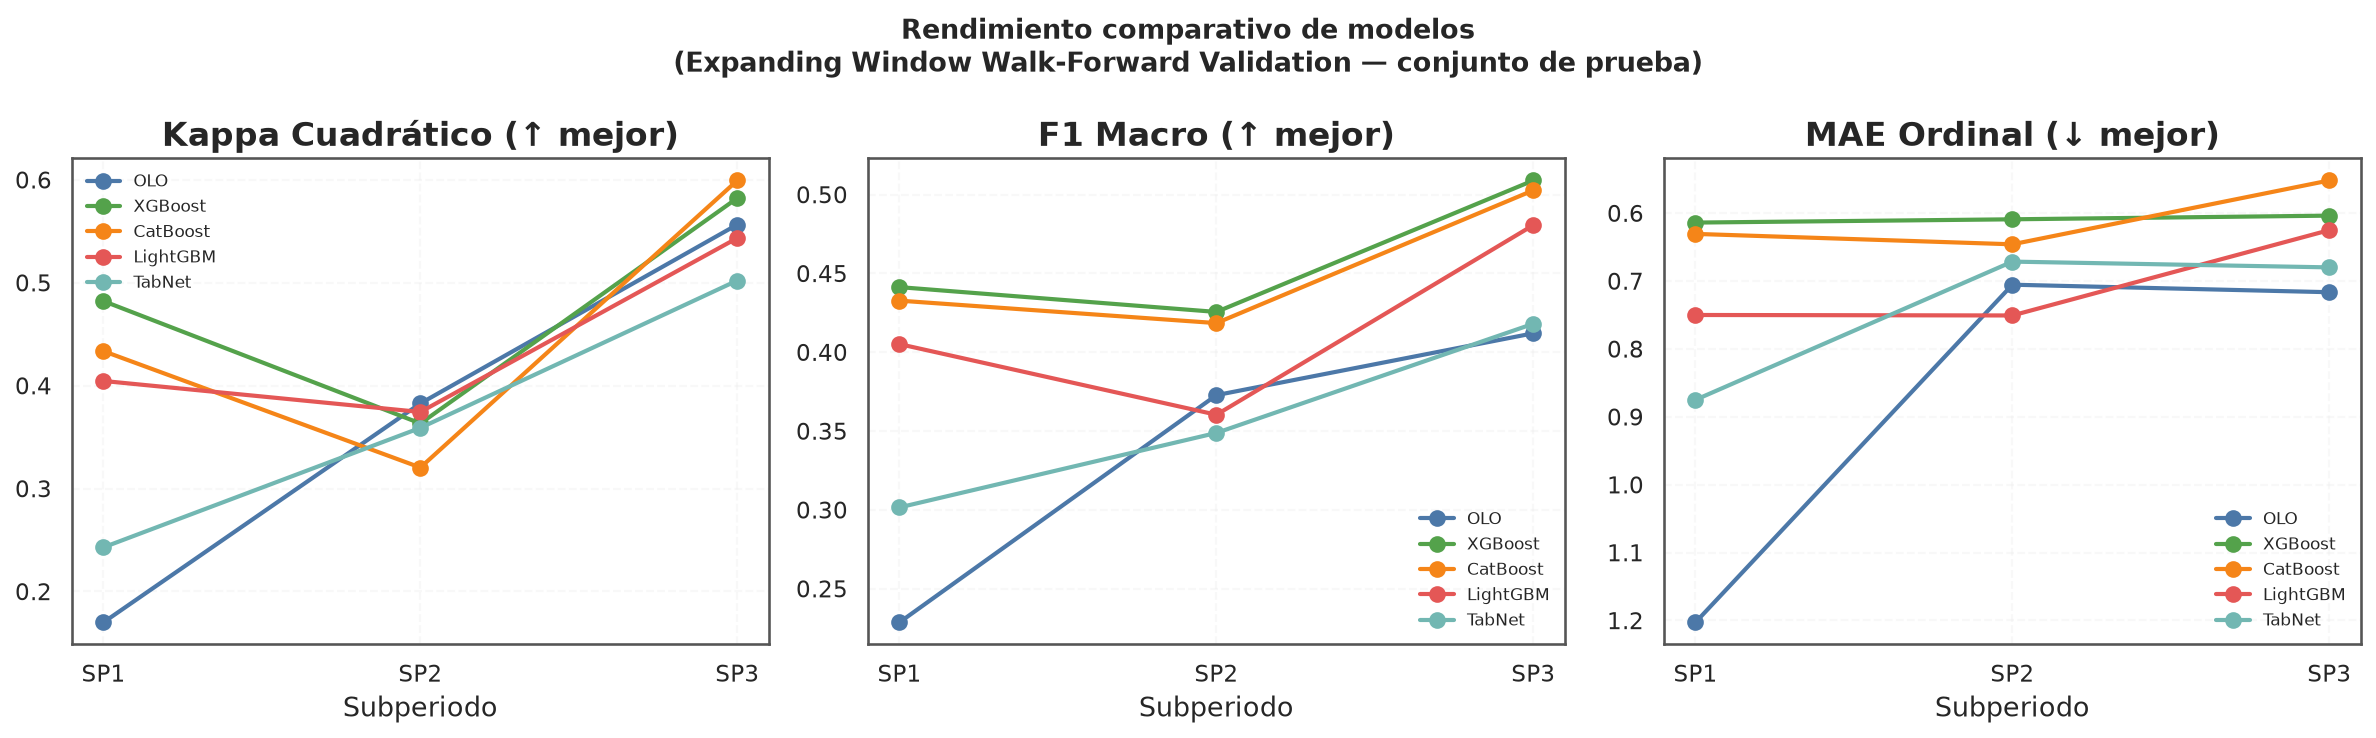

In [4]:
# =============================================================================
# Gráficos de rendimiento por modelo y subperiodo
# =============================================================================
plot_metricas_comparativas(df_test, nombre_archivo="03_metricas_comparativas")

  ✓ Figura guardada: 03_val_vs_test.png


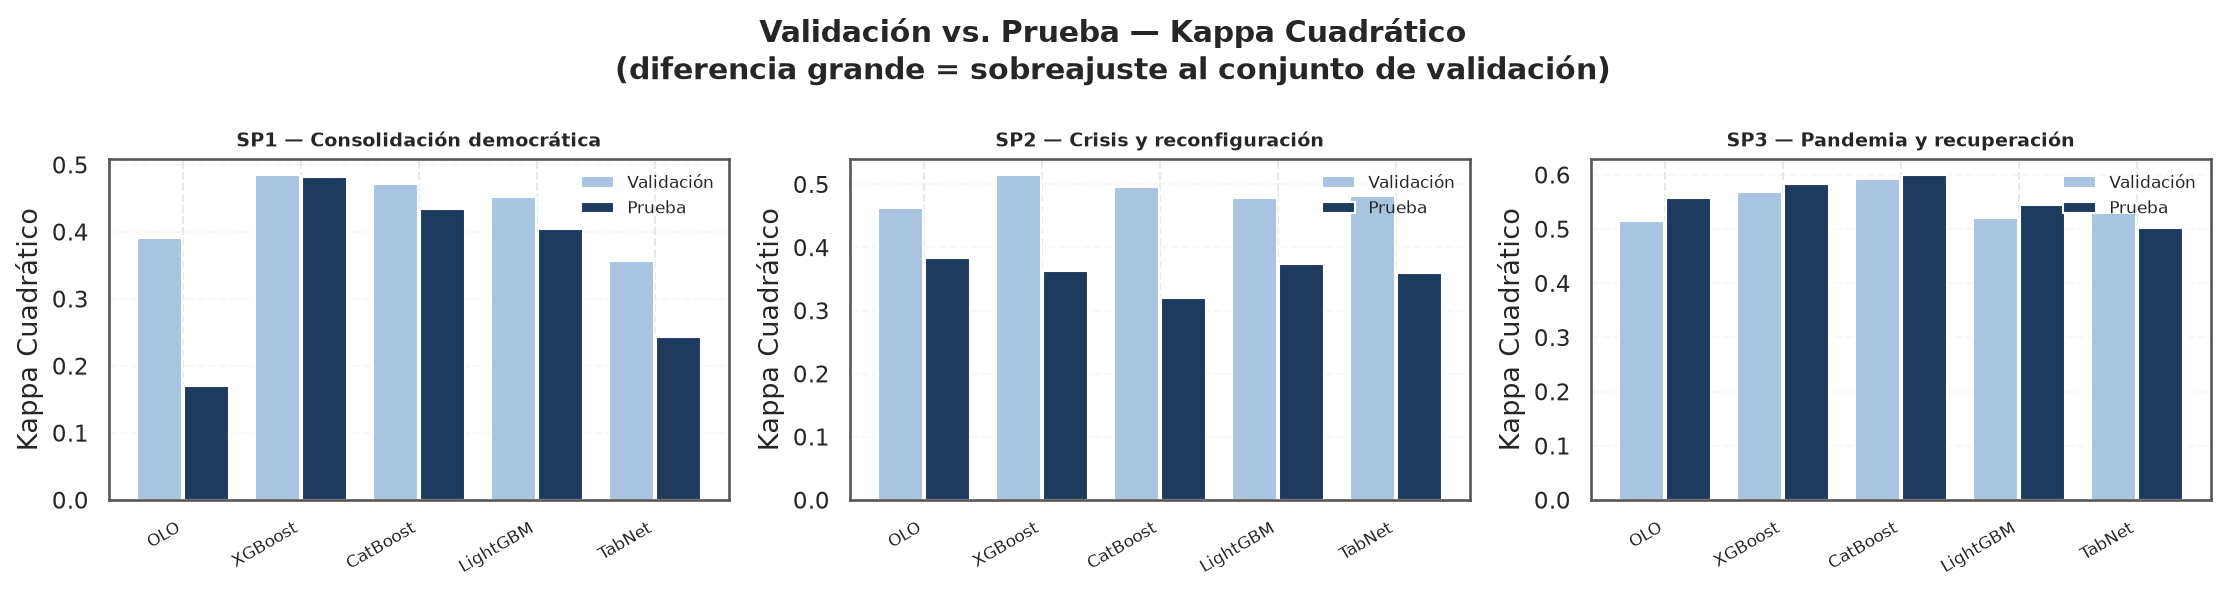

In [5]:
# =============================================================================
# Comparación validación vs. prueba para detectar sobreajuste
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Validación vs. Prueba — Kappa Cuadrático\n"
             "(diferencia grande = sobreajuste al conjunto de validación)",
             fontweight="bold")

for ax, sp in zip(axes, ["SP1","SP2","SP3"]):
    sub_val  = df_val[df_val["subperiodo"] == sp].set_index("modelo")["kappa_cuadratico"]
    sub_test = df_test[df_test["subperiodo"] == sp].set_index("modelo")["kappa_cuadratico"]

    modelos_comunes = [m for m in MODELOS if m in sub_val.index and m in sub_test.index]
    x = np.arange(len(modelos_comunes))

    ax.bar(x - 0.2, [sub_val[m] for m in modelos_comunes], 0.38,
           label="Validación", color="#A8C4E0", edgecolor="white")
    ax.bar(x + 0.2, [sub_test[m] for m in modelos_comunes], 0.38,
           label="Prueba", color="#1E3A5F", edgecolor="white")
    ax.set_title(f"{sp} — {SUBPERIODOS[sp]['descripcion'].split('(')[0].strip()}",
                 fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos_comunes, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Kappa Cuadrático")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

save_figure("03_val_vs_test")
plt.show()

## 5. Matrices de confusión

In [6]:
# =============================================================================
# Reconstruir predicciones para las matrices de confusión
# =============================================================================
# Se cargan los pipelines y se regeneran predicciones sobre el test set.
# El parámetro CONFUSION_TODOS_MODELOS controla si se muestran todos
# los modelos o solo el mejor por subperiodo.
# =============================================================================

import joblib

resultados_cm: Dict = {}   # clave: (modelo, sp) → (y_true, y_pred)

for sp in ["SP1","SP2","SP3"]:
    df_te = cargar_split_parquet(sp, "test")
    y_te  = df_te[COL_TARGET].astype(int).values

    for modelo in MODELOS:
        try:
            art = cargar_pipeline(modelo, sp)
            tipo = art["tipo_modelo"]
            feats = art["features"]
            X_te  = df_te[[f for f in feats if f in df_te.columns]]
            X_te  = X_te.reindex(columns=feats)

            if tipo == "olo":
                from utils.preprocessing import imputar, normalizar
                # Necesitamos el mismo preprocesamiento que en entrenamiento
                # Para la evaluación: usar el imputer/scaler ya guardados
                X_imp = pd.DataFrame(
                    art["imp_num"].transform(X_te), columns=feats)
                X_sc  = pd.DataFrame(
                    art["scaler"].transform(X_imp), columns=feats)
                y_pred = art["modelo"].predict(X_sc.values)

            elif tipo == "tabnet":
                X_imp = pd.DataFrame(
                    art["imp_num"].transform(X_te), columns=feats)
                X_sc  = pd.DataFrame(
                    art["scaler"].transform(X_imp), columns=feats)
                y_pred = art["modelo"].predict(X_sc.values.astype(np.float32))

            else:  # trees
                X_in = X_te.copy()
                if modelo == "CatBoost":
                    for col in art.get("vars_categoricas", []):
                        if col in X_in.columns:
                            X_in[col] = X_in[col].fillna(-999).astype(int).astype(str)
                y_raw  = art["modelo"].predict(X_in)
                y_pred = y_raw.flatten() if hasattr(y_raw, "flatten") else y_raw

            resultados_cm[(modelo, sp)] = (y_te, y_pred)
        except FileNotFoundError:
            print(f"  ⚠ Pipeline no encontrado: {modelo} — {sp}")
        except Exception as e:
            print(f"  ⚠ Error en {modelo} — {sp}: {e}")

print(f"✓ Predicciones reconstruidas para {len(resultados_cm)} combinaciones")

  ⚠ Error en OLO — SP1: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- S_200



  ⚠ Error en LightGBM — SP1: train and valid dataset categorical_feature do not match.


  ⚠ Error en TabNet — SP1: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- S_200

  ⚠ Error en OLO — SP2: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- S_200

  ⚠ Error en LightGBM — SP2: train and valid dataset categorical_feature do not match.


  ⚠ Error en TabNet — SP2: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- S_200

  ⚠ Error en OLO — SP3: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- S_200

  ⚠ Error en LightGBM — SP3: train and valid dataset categorical_feature do not match.
  ⚠ Error en TabNet — SP3: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- S_200

✓ Predicciones reconstruidas para 6 combinaciones


  Mejor modelo SP1: XGBoost
  Mejor modelo SP2: OLO
  Mejor modelo SP3: CatBoost


  ✓ Figura guardada: 03_matrices_confusion.png


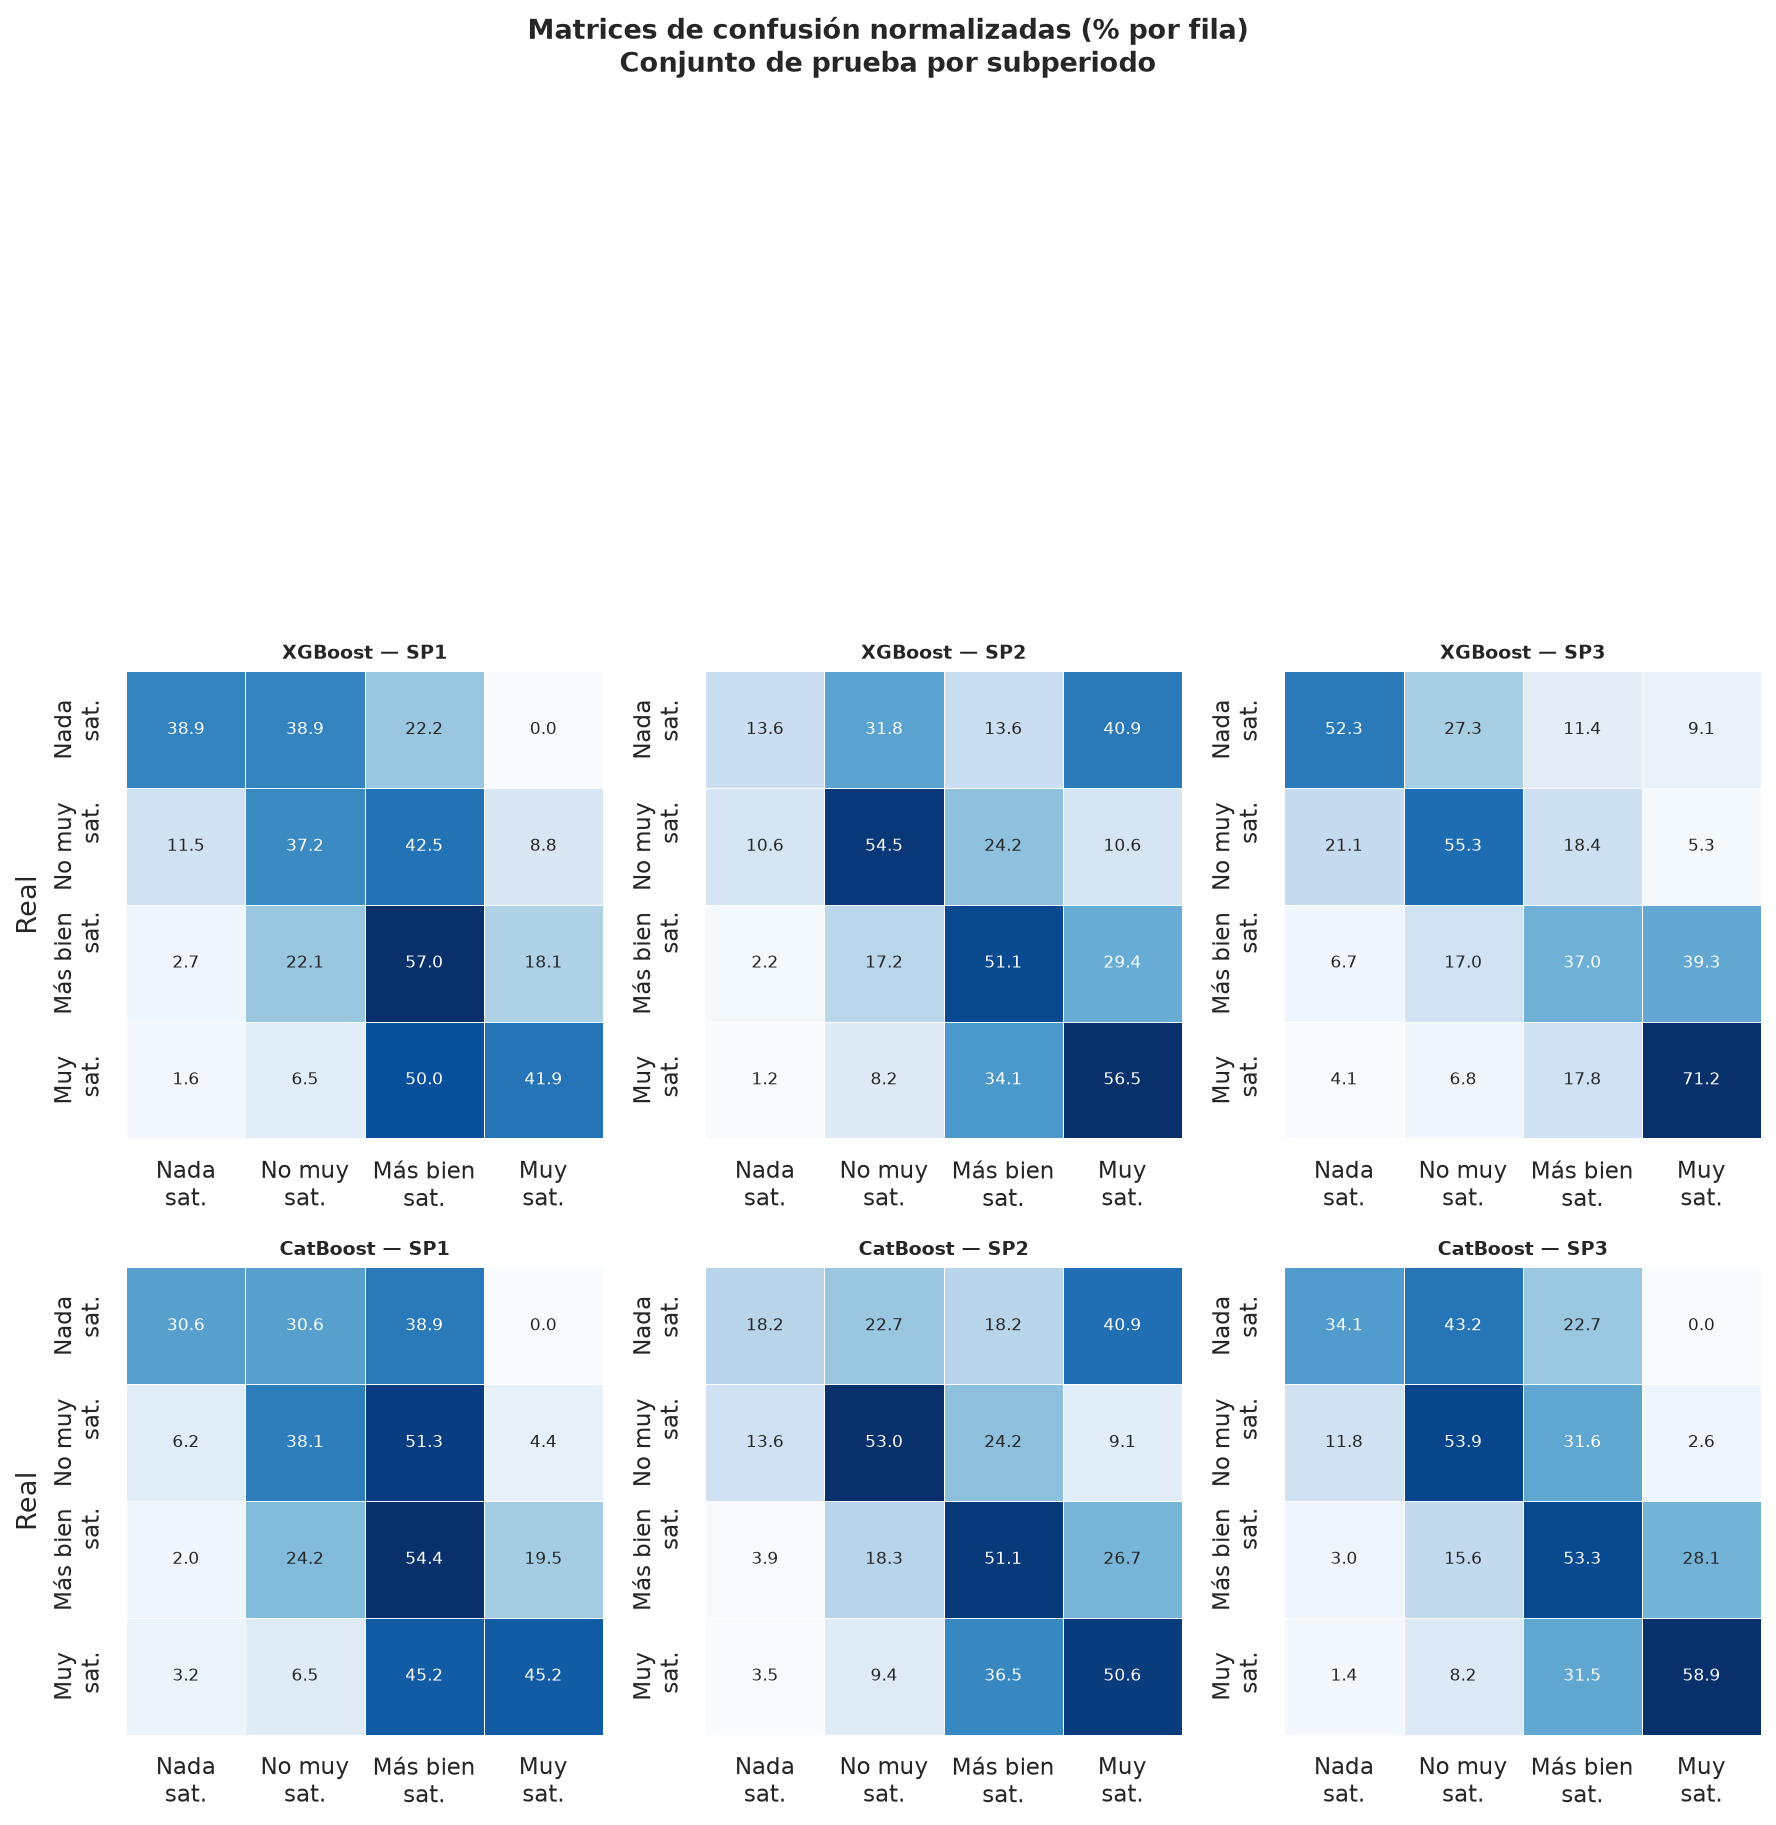

In [7]:
# Mejor modelo por subperiodo
mejor_por_sp = {}
for sp in ["SP1","SP2","SP3"]:
    try:
        mejor_por_sp[sp] = cargar_mejor_modelo(sp, METRICA_PRINCIPAL)
        print(f"  Mejor modelo {sp}: {mejor_por_sp[sp]}")
    except Exception as e:
        print(f"  ⚠ {sp}: {e}")

# Generar matrices
mejor_global = cargar_mejor_modelo("SP3", METRICA_PRINCIPAL)

plot_matrices_confusion(
    resultados_cm,
    solo_mejor     = not CONFUSION_TODOS_MODELOS,
    mejor_modelo   = mejor_global,
    nombre_archivo = "03_matrices_confusion",
)

## 6. Análisis de rendimiento por subregión y país

In [8]:
# =============================================================================
# MAE ordinal por país en el conjunto de prueba (SP3)
# Venezuela y Nicaragua excluidos del análisis por país (ver metodología).
# =============================================================================
from sklearn.metrics import mean_absolute_error

filas_pais = []
sp_eval    = "SP3"   # análisis principal sobre el subperiodo más reciente

df_te_full = cargar_split_parquet(sp_eval, "test")

# Añadir columna de país si está disponible
if COL_PAIS not in df_te_full.columns:
    print("⚠ Columna pais_nombre no disponible en el Parquet de test.")
    print("  Para el análisis por país se necesita el DataFrame completo.")
else:
    y_te_full = df_te_full[COL_TARGET].astype(int).values
    paises_test = df_te_full[COL_PAIS].unique()
    paises_analizar = [p for p in paises_test if p not in PAISES_EXCLUIR_TEST]

    for modelo in MODELOS:
        if (modelo, sp_eval) not in resultados_cm:
            continue
        y_pred_full = resultados_cm[(modelo, sp_eval)][1]

        for pais in paises_analizar:
            mask = df_te_full[COL_PAIS] == pais
            if mask.sum() < 10:
                continue
            mae = mean_absolute_error(y_te_full[mask], y_pred_full[mask])
            # Identificar subregión
            subregion = "Sin clasificar"
            for sr, paises_sr in SUBREGIONES.items():
                if pais in paises_sr:
                    subregion = sr
                    break
            filas_pais.append({
                "modelo": modelo, "subperiodo": sp_eval,
                "pais": pais, "subregion": subregion,
                "mae_ordinal": mae, "n": int(mask.sum()),
            })

    df_mae_pais = pd.DataFrame(filas_pais)
    if not df_mae_pais.empty:
        print(f"Análisis por país — {sp_eval}:")
        print(df_mae_pais.groupby(["subregion","modelo"])["mae_ordinal"]
              .mean().unstack().round(3).to_string())
        df_mae_pais.to_csv(
            PATHS["FOLDER_RESULTS_TABLES"] / f"mae_por_pais_{sp_eval}.csv",
            index=False)
        print("\n✓ Tabla guardada")
    else:
        print("⚠ Sin datos por país — verificar Parquet de test.")

⚠ Columna pais_nombre no disponible en el Parquet de test.
  Para el análisis por país se necesita el DataFrame completo.


In [9]:
# Gráfico MAE por país
if 'df_mae_pais' in dir() and not df_mae_pais.empty:
    plot_rendimiento_por_pais(df_mae_pais, subperiodo=sp_eval,
                              nombre_archivo="03_mae_por_pais")

# Heatmap: MAE por subregión × subperiodo para el mejor modelo
if 'df_mae_pais' in dir() and not df_mae_pais.empty:
    mejor_m = cargar_mejor_modelo("SP3", METRICA_PRINCIPAL)
    df_sr   = (df_mae_pais[df_mae_pais["modelo"] == mejor_m]
               .groupby(["subregion","subperiodo"])["mae_ordinal"].mean()
               .unstack())

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(df_sr, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.3, ax=ax, cbar_kws={"label": "MAE Ordinal"})
    ax.set_title(f"MAE Ordinal por subregión — {mejor_m}",
                 fontweight="bold")
    save_figure("03_mae_subregion_heatmap")
    plt.show()

## 7. Test estadístico de diferencias entre modelos

**Test de Friedman** (Demšar, 2006): evalúa si las diferencias de rendimiento
entre modelos son estadísticamente significativas considerando todos los
subperiodos como bloques.

**Nota metodológica:** con n=3 subperiodos la potencia estadística es baja.
Los resultados se interpretan como evidencia indicativa, no concluyente.

In [10]:
if EJECUTAR_TEST_ESTADISTICO:
    from scipy.stats import friedmanchisquare

    # Construir matriz: modelos × subperiodos (solo test)
    sps_ord = ["SP1","SP2","SP3"]
    matriz  = []
    for modelo in MODELOS:
        fila = []
        for sp in sps_ord:
            sub = df_test[(df_test["modelo"]==modelo) & (df_test["subperiodo"]==sp)]
            fila.append(sub[METRICA_PRINCIPAL].values[0] if len(sub) > 0 else np.nan)
        matriz.append(fila)
    mat = np.array(matriz)   # shape: (5 modelos × 3 subperiodos)

    # Test de Friedman (k=modelos como tratamientos, n=subperiodos como bloques)
    stat, p_val = friedmanchisquare(*mat.T)   # transponer: filas=bloques
    print(f"Test de Friedman")
    print(f"  Estadístico χ²F = {stat:.4f}")
    print(f"  p-valor          = {p_val:.4f}")
    print(f"  Conclusión       : {'Diferencias significativas (α=0.05)' if p_val < 0.05 else 'Sin evidencia de diferencias significativas (α=0.05)'}")
    print(f"\n  ⚠ Nota: n=3 bloques implica baja potencia estadística.")
    print(f"         Los resultados son indicativos.")

    # Post-hoc de Nemenyi si Friedman es significativo
    if p_val < 0.05:
        try:
            from scikit_posthocs import posthoc_nemenyi_friedman
            df_nemenyi = posthoc_nemenyi_friedman(mat.T)
            df_nemenyi.index   = MODELOS
            df_nemenyi.columns = MODELOS
            print("\nPost-hoc Nemenyi (p-valores):")
            print(df_nemenyi.round(4).to_string())
            df_nemenyi.to_csv(
                PATHS["FOLDER_RESULTS_TABLES"] / "nemenyi_pvalues.csv")
        except ImportError:
            print("\n  ⚠ scikit-posthocs no instalado.")
            print("     Instalar con: pip install scikit-posthocs")
else:
    print("Test estadístico desactivado (EJECUTAR_TEST_ESTADISTICO = False)")

Test de Friedman
  Estadístico χ²F = 7.6000
  p-valor          = 0.0224
  Conclusión       : Diferencias significativas (α=0.05)

  ⚠ Nota: n=3 bloques implica baja potencia estadística.
         Los resultados son indicativos.

Post-hoc Nemenyi (p-valores):
             OLO  XGBoost  CatBoost  LightGBM  TabNet
OLO       1.0000   0.9380    0.9990    1.0000  0.8402
XGBoost   0.9380   1.0000    0.9858    0.9380  0.3692
CatBoost  0.9990   0.9858    1.0000    0.9990  0.6968
LightGBM  1.0000   0.9380    0.9990    1.0000  0.8402
TabNet    0.8402   0.3692    0.6968    0.8402  1.0000


## 8. Selección del modelo principal para análisis XAI

In [11]:
# =============================================================================
# El modelo con mejor Kappa Cuadrático en SP3 (conjunto de prueba) se define
# como modelo principal para el análisis de explicabilidad (notebook 04).
# Esta selección puede sobreescribirse manualmente en el notebook 04.
# =============================================================================

mejor_modelo_xai = cargar_mejor_modelo("SP3", METRICA_PRINCIPAL)

print(f"Modelo principal para análisis XAI: {mejor_modelo_xai}")
print(f"Criterio: mayor {METRICA_PRINCIPAL} en SP3 (conjunto de prueba)")
print()
print("Ranking completo SP3:")
sub_sp3 = (df_test[df_test["subperiodo"]=="SP3"]
           .sort_values(METRICA_PRINCIPAL, ascending=False))
for _, row in sub_sp3.iterrows():
    marca = " ← SELECCIONADO" if row["modelo"] == mejor_modelo_xai else ""
    print(f"  {row['modelo']:<12}: {METRICA_PRINCIPAL}={row[METRICA_PRINCIPAL]:.4f}{marca}")

# Guardar selección para uso en notebooks 04–06
seleccion = {"modelo_xai": mejor_modelo_xai, "metrica": METRICA_PRINCIPAL,
             "subperiodo_referencia": "SP3"}
import json
ruta_sel = PATHS["FOLDER_RESULTS"] / "modelo_xai_seleccionado.json"
ruta_sel.write_text(json.dumps(seleccion, indent=2))
print(f"\n✓ Selección guardada: {ruta_sel}")

Modelo principal para análisis XAI: CatBoost
Criterio: mayor kappa_cuadratico en SP3 (conjunto de prueba)

Ranking completo SP3:
  CatBoost    : kappa_cuadratico=0.5994 ← SELECCIONADO
  XGBoost     : kappa_cuadratico=0.5822
  OLO         : kappa_cuadratico=0.5565
  LightGBM    : kappa_cuadratico=0.5434
  TabNet      : kappa_cuadratico=0.5022

✓ Selección guardada: ../results/modelo_xai_seleccionado.json


## 9. Resumen y guardado

In [12]:
# =============================================================================
# Resumen ejecutivo del notebook 03
# =============================================================================
print("=" * 60)
print("RESUMEN — Evaluación comparativa de modelos")
print("=" * 60)
print(f"  Subperiodos evaluados : SP1, SP2, SP3")
print(f"  Modelos evaluados     : {', '.join(MODELOS)}")
print(f"  Métrica principal     : {METRICA_PRINCIPAL}")
print()
print("Mejor modelo por subperiodo (Kappa Cuadrático):")
for sp in ["SP1","SP2","SP3"]:
    try:
        m = cargar_mejor_modelo(sp, METRICA_PRINCIPAL)
        val = df_test[(df_test["modelo"]==m) & (df_test["subperiodo"]==sp)][METRICA_PRINCIPAL].values[0]
        print(f"  {sp}: {m} ({val:.4f})")
    except:
        print(f"  {sp}: sin datos")
print()
print("Archivos generados en results/:")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*.csv")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_FIGURES"].glob("03_*.png")):
    print(f"  {f.name}")

RESUMEN — Evaluación comparativa de modelos
  Subperiodos evaluados : SP1, SP2, SP3
  Modelos evaluados     : OLO, XGBoost, CatBoost, LightGBM, TabNet
  Métrica principal     : kappa_cuadratico

Mejor modelo por subperiodo (Kappa Cuadrático):
  SP1: XGBoost (0.4822)
  SP2: OLO (0.3827)
  SP3: CatBoost (0.5994)

Archivos generados en results/:
  metricas_completas_test.csv
  metricas_kappa_pivot.csv
  nemenyi_pvalues.csv
  03_matrices_confusion.png
  03_metricas_comparativas.png
  03_val_vs_test.png
